# The Big Project begins!!

## The Product Pricer

A model that can estimate how much something costs, from its description.

## Data Curation Part 1

Today we'll begin our scrubbing and curating our dataset by focusing on a subset of the data: Home Appliances.

The dataset is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023

And the folder with all the product datasets is here:  
https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/tree/main/raw/meta_categories

In [1]:
# imports

import os
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset, Dataset, DatasetDict
import matplotlib.pyplot as plt

In [2]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HUGGINGFACEHUB_API_KEY', 'your-key-if-not-using-env')

In [3]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## One more import - the Item class

If you get an error that you need to agree to Meta's terms when you run this, then follow the link it provides you and follow their instructions. You should get approved by Meta within minutes.

See the last cell in [this colab](https://colab.research.google.com/drive/1deJO03YZTXUwcq2vzxWbiBhrRuI29Vo8?usp=sharing#scrollTo=FqyF5jZQkIl_) for steps to take if Meta doesn't approve.

Any problems - message me or email me!  

With thanks to student Dr John S. for pointing out that this import needs to come after signing in to HF

In [4]:
from items import Item

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

In [5]:
%matplotlib inline

## Load our dataset

In the next cell, we load in the dataset from huggingface.

If this gives you an error like "trust_remote_code is no longer supported", then please run this command in a new cell: `!pip install datasets==3.6.0` and then restart the Kernel, and try again.

In [20]:
def load_amazon_meta(category: str):
    from datasets import load_dataset
    url = f"https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw_meta_{category}/*.parquet"
    return load_dataset("parquet", data_files=url)

In [21]:
dataset = load_amazon_meta("Electronics")
print(dataset)
print(dataset['train'][0])


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


full-00000-of-00010.parquet:   0%|          | 0.00/220M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


full-00001-of-00010.parquet:   0%|          | 0.00/214M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


...

full-00008-of-00010.parquet:   0%|          | 0.00/170M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


full-00009-of-00010.parquet:   0%|          | 0.00/164M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author'],
        num_rows: 1610012
    })
})
{'main_category': 'All Electronics', 'title': 'FS-1051 FATSHARK TELEPORTER V3 HEADSET', 'average_rating': 3.5, 'rating_number': 6, 'features': [], 'description': ['Teleporter V3 The “Teleporter V3” kit sets a new level of value in the FPV world with Fat Shark renowned performance and quality. The fun of FPV is experienced firsthand through the large screen FPV headset with integrated NexwaveRF receiver technology while simultaneously recording onboard HD footage with the included “PilotHD” camera. The “Teleporter V3” kit comes complete with everything you need to step into the cockpit of your FPV vehicle. We’ve included our powerful 250mW 5.8Ghz transmitter, 25 degree FOV headset (largest QVGA

In [22]:
print(f"Number of Appliances: {len(dataset):,}")

Number of Appliances: 1


In [24]:
# Investigate a particular datapoint
datapoint = dataset['train'][2]


In [25]:
# Investigate

print(datapoint["title"])
print(datapoint["description"])
print(datapoint["features"])
print(datapoint["details"])
print(datapoint["price"])

Digi-Tatoo Decal Skin Compatible With MacBook Pro 13 inch (Model A2338/ A2289/ A2251) - Protective and Decorative Full Body Laptop Skin Decal Sticker, Anti-Scratch Vinly Skin Sticker Wrap [Fresh Marble]
[]
['WARNING: Please IDENTIFY MODEL NUMBER on the bottom of your Macbook. Only fits for model A2338/ A2289/ A2251 (Macbook Pro 13" w/ Touch Bar, 2022/2020 release).', 'Extra Care Yet Not Bulky. Our skin is capable of protecting the surface of your Macbook from daily scratches, dust, oil, water and fingerprint. Your Macbook remains fresh some years later.', 'Elegant Style. Our stylish design and printing tech give your Macbook a 360 degree decorative and impressive looking. Take it out and get tons of compliments.', 'Easy Apply. Easy, bubble-free installation and goo-free removal. Installation guide is well documented in paper material and video format.', '100% SATISFACTION GUARANTEED. We use best vinyl material and printing technology and offer premium service. Full refund is guaranteed

In [27]:
# How many have prices?

prices = 0
for datapoint in dataset['train']:
    try:
        price = float(datapoint["price"])
        if price > 0:
            prices += 1
    except (ValueError, TypeError, KeyError):
        pass

print(f"There are {prices:,} with prices which is {prices/len(dataset['train'])*100:,.1f}%")

There are 526,439 with prices which is 32.7%


In [29]:
# For those with prices, gather the price and the length

prices = []
lengths = []
for datapoint in dataset['train']:
    try:
        price = float(datapoint["price"])
        if price > 0:
            prices.append(price)
            contents = datapoint["title"] + str(datapoint["description"]) + str(datapoint["features"]) + str(datapoint["details"])
            lengths.append(len(contents))
    except ValueError as e:
        pass

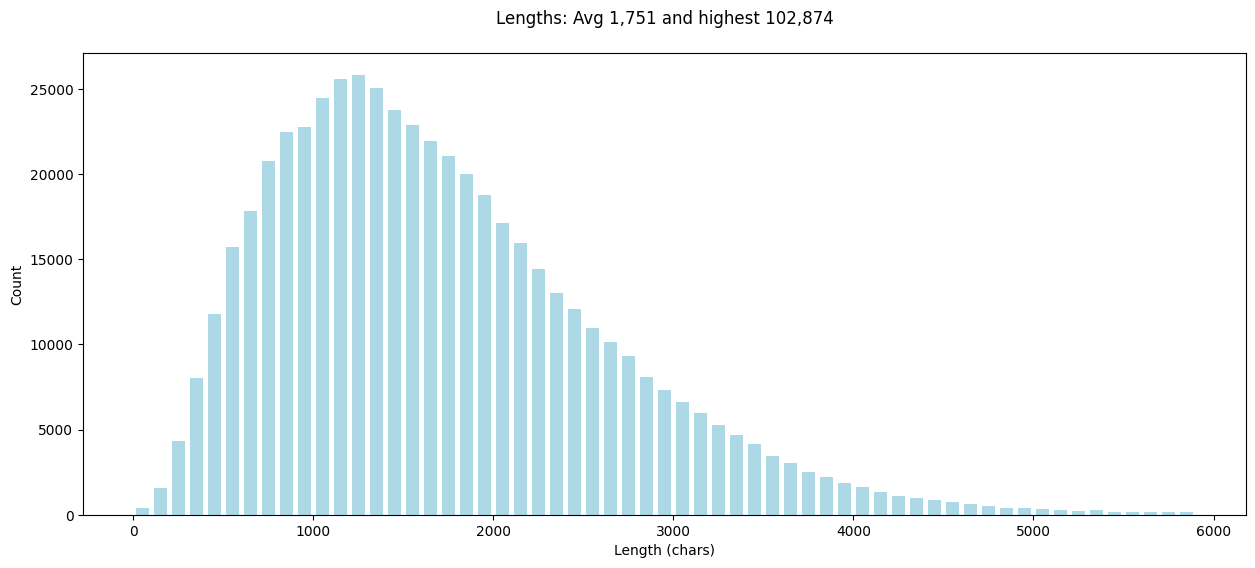

In [30]:
# Plot the distribution of lengths

plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 6000, 100))
plt.show()

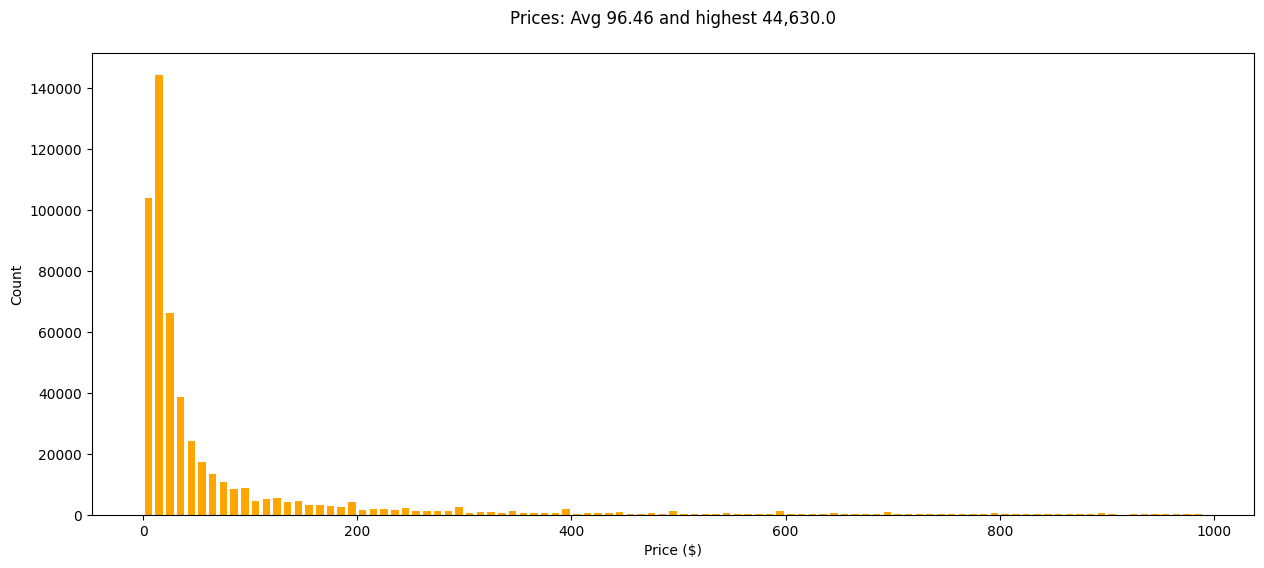

In [31]:
# Plot the distribution of prices

plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.2f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="orange", bins=range(0, 1000, 10))
plt.show()

In [34]:
# So what is this item??

for datapoint in dataset['train']:
    try:
        price = float(datapoint["price"])
        if price > 21000:
            print(datapoint['title'])
    except ValueError as e:
        pass

Sony VPLVZ1000ES Ultra-Short Throw 4K HDR Home Theatre Projector
LG 97-Inch Class OLED evo Gallery Edition G2 Series Alexa Built-in 4K Smart TV, 120Hz Refresh Rate, AI-Powered, Dolby Vision IQ and Dolby Atmos, WiSA Ready, Cloud Gaming (OLED97G2PUA, 2022)
Wacom Intuos Small Refurbished Graphics Drawing Tablet
Sony VPLVW885ES 4K HDR Laser Home Theater Video Projector
Intelligent Security Patrol Service Robot Autonomous Navigation Robot (Black)


KeyboardInterrupt: 

This is the closest I can find - looks like it's going at a bargain price!!

https://www.amazon.com/TurboChef-Electric-Countertop-Microwave-Convection/dp/B01D05U9NO/

## Now it's time to curate our dataset

We select items that cost between 1 and 999 USD

We will be create Item instances, which truncate the text to fit within 180 tokens using the right Tokenizer

And will create a prompt to be used during Training.

Items will be rejected if they don't have sufficient characters.

## But why 180 tokens??

A student asked me a great question - why are we truncating to 180 tokens? How did we determine that number? (Thank you Moataz A. for the excellent question).

The answer: this is an example of a "hyper-parameter". In other words, it's basically trial and error! We want a sufficiently large number of tokens so that we have enough useful information to gauge the price. But we also want to keep the number low so that we can train efficiently. You'll see this in action in Week 7.

I started with a number that seemed reasonable, and experimented with a few variations before settling on 180. If you have time, you should do the same! You might find that you can beat my results by finding a better balance. This kind of trial-and-error might sound a bit unsatisfactory, but it's a crucial part of the data science R&D process.

There's another interesting reason why we might favor a lower number of tokens in the training data. When we eventually get to use our model at inference time, we'll want to provide new products and have it estimate a price. And we'll be using short descriptions of products - like 1-2 sentences. For best performance, we should size our training data to be similar to the inputs we will provide at inference time.

## But I see in items.py it constrains inputs to 160 tokens?

Another great question from Moataz A.! The description of the products is limited to 160 tokens because we add some more text before and after the description to turn it into a prompt. That brings it to around 180 tokens in total.



In [35]:
# Create an Item object for each with a price

items = []
for datapoint in dataset['train']:
    try:
        price = float(datapoint["price"])
        if price > 0:
            item = Item(datapoint, price)
            if item.include:
                items.append(item)
    except ValueError as e:
        pass

print(f"There are {len(items):,} items")

There are 450,834 items


In [36]:
# Look at the first item

items[1]

<NotoCity Compatible with Vivoactive 4 band 22mm Quick Release Silicone Bands/Garmin Darth Vader/First Avenger/Polar Vantage Smartwatch Sport Breathable Strap Replacement for Gear S3 Classic Watchband = $9.99>

In [37]:
# Investigate the prompt that will be used during training - the model learns to complete this

print(items[100].prompt)

How much does this cost to the nearest dollar?

ICE 100mm ND1000 Square Filter Neutral Density 10 Stop Optical Glass fits Cokin Z
ND1000 Filter. 10 Stop exposure correction. No color cast. Optical Glass. Compare to Lee Big Stopper. Fits Cokin Z-100, Lee & Hitech 100mm drop in Filter holders. 10 Stop exposure correction. Compare to Lee Big Stopper. Fits Cokin Z-100, Lee & Hitech 100mm drop in Filter holders. Optical Glass. No color cast. Dimensions 7 x 4.8 x 0.9 inches, Weight 3.84 ounces, model number Rank Camera Lens Neutral Density Filters 497, Is Discontinued No, Available September 12, 2012, Manufacturer ICE, Brand ICE, Material Optical Glass

Price is $50.00


In [38]:
# Investigate the prompt that will be used during testing - the model has to complete this

print(items[100].test_prompt())

How much does this cost to the nearest dollar?

ICE 100mm ND1000 Square Filter Neutral Density 10 Stop Optical Glass fits Cokin Z
ND1000 Filter. 10 Stop exposure correction. No color cast. Optical Glass. Compare to Lee Big Stopper. Fits Cokin Z-100, Lee & Hitech 100mm drop in Filter holders. 10 Stop exposure correction. Compare to Lee Big Stopper. Fits Cokin Z-100, Lee & Hitech 100mm drop in Filter holders. Optical Glass. No color cast. Dimensions 7 x 4.8 x 0.9 inches, Weight 3.84 ounces, model number Rank Camera Lens Neutral Density Filters 497, Is Discontinued No, Available September 12, 2012, Manufacturer ICE, Brand ICE, Material Optical Glass

Price is $


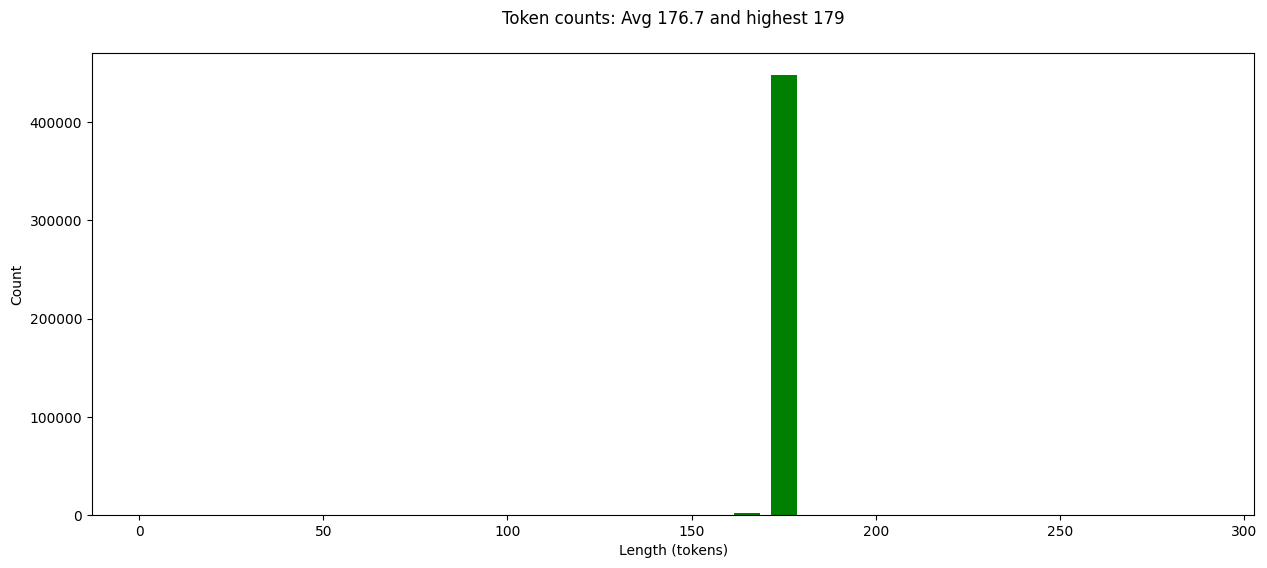

In [39]:
# Plot the distribution of token counts

tokens = [item.token_count for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Token counts: Avg {sum(tokens)/len(tokens):,.1f} and highest {max(tokens):,}\n")
plt.xlabel('Length (tokens)')
plt.ylabel('Count')
plt.hist(tokens, rwidth=0.7, color="green", bins=range(0, 300, 10))
plt.show()

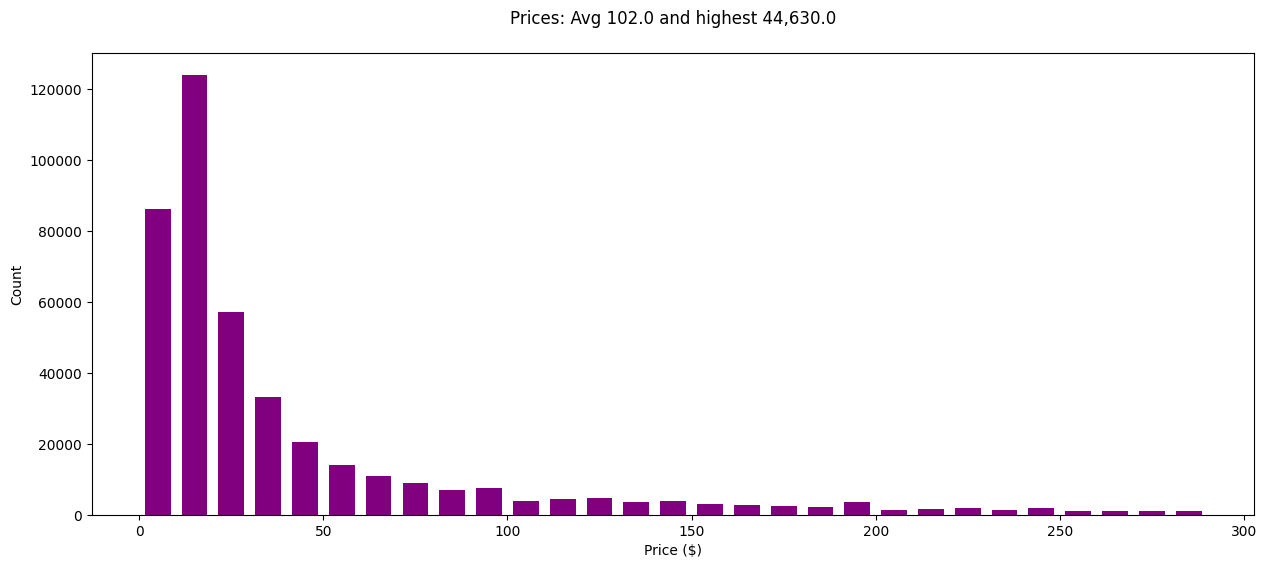

In [40]:
# Plot the distribution of prices

prices = [item.price for item in items]
plt.figure(figsize=(15, 6))
plt.title(f"Prices: Avg {sum(prices)/len(prices):,.1f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="purple", bins=range(0, 300, 10))
plt.show()

## Sidenote

If you like the variety of colors that matplotlib can use in its charts, you should bookmark this:

https://matplotlib.org/stable/gallery/color/named_colors.html

## Todos for you:

- Review the Item class and check you're comfortable with it
- Examine some Item objects, look at the training prompt with `item.prompt` and test prompt with `item.test_prompt()`
- Make some more histograms to better understand the data

## Next time we will combine with many other types of product

Like Electronics and Automotive. This will give us a massive dataset, and we can then be picky about choosing a subset that will be most suitable for training.

AttributeError: 'Item' object has no attribute 'description'